In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import pandas as pd
import pickle
import healsparse
import healpy as hp
import sys
import treecorr

plt.rcParams.update({
    'font.family':'serif',
    'font.size':12.0,
    'axes.labelsize': 'x-large',
    'xtick.labelsize':'large',
    'ytick.labelsize':'large',
    'axes.titlesize':'x-large',
    'legend.fontsize': 'large',
    'xtick.direction':'in',
    'ytick.direction':'in',
    'lines.linewidth':2,
    'patch.linewidth':2, # for hist
    'lines.color':'black',
    'mathtext.fontset' : 'stix',
    'figure.titlesize': 'xx-large',
    'figure.facecolor':  (1.0, 1.0, 1.0, 1.0),
    'axes.facecolor':    (1.0, 1.0, 1.0, 1.0), 
    'savefig.facecolor': (1.0, 1.0, 1.0, 1.0)})

colors = ['dodgerblue', 'darkgreen', 'darkorange', 'darkred', 'violet', 'slateblue']

In [2]:
props_bfd = ['ra', 'dec', 'e1', 'e2', 'DNF_Z', 'DNF_Z_MC', 'P', 'Q0', 'Q1', 'R00', 'R01', 'R11',
             'mag_auto_g', 'mag_auto_i', 'mag_auto_r', 'mag_auto_z', 'nz_R_weight', 'tomo_bin', 'id']

props_maglim = ['ra', 'dec', 'Z_MEAN', 'Z_MC',
                'BDF_MAG_CORRDERED_G', 'BDF_MAG_CORRDERED_I', 'BDF_MAG_CORRDERED_R', 'BDF_MAG_CORRDERED_Y', 'BDF_MAG_CORRDERED_Z'] 
zs_maglim = [0.2, 0.4, 0.55, 0.7, 0.85, 0.95, 1.05]

props_ran = ['ra', 'dec', 'z'] #weight?

zbins_s = 4
zbins_l = 6

In [3]:
dir_des = '/global/cfs/cdirs/des/'

bfd_cat = dir_des + 'y6-shear-catalogs/BFD_v2/BFD_v2_6_22_23_blinded.fits'
maglim_cat = dir_des + 'nweaverd/des_y6/maglim_plusplus/y6maglim_VIPERS_a18_b4_v2.0_pzcols_wisecols.fits'
ran_cat = dir_des + 'jelvinpo/y6_randoms/y6maglim_randoms_rr40.0_y6_maglim_jointmask_fiducial.fits'

shear_map = dir_des + 'y6-shear-catalogs/y6-combined-hleda-gaiafull-des-stars-hsmap16384-nomdet-v3.fits'
lss_map = dir_des + 'monroy/Y6A2/maglim/sp_outliers_analysis/maglim_mask/jointmasks_fiducial/Y6LSSBAO_V2_MASK_WITHDEPTH_up_to_22.2_jointmask_3.5iqr_sps_0.01percent_sb_mean_0.5max_val_neb_mean_gcs_bit64_joint_vl05_vl10_vlim_zmax_gaia512_shear_flim0.8_bad_regions_gold20.fits.gz'

dir_elisa = dir_des + 'elisa/ggl_y6_bfd/'

In [5]:
def convert_to_pix_coord(ra, dec, nside=1024,nest=False):
    """
    Converts RA,DEC to hpix coordinates
    """
    theta = (90.0 - dec) * np.pi / 180.
    phi = ra * np.pi / 180.
    pix = hp.ang2pix(nside, theta, phi, nest=nest)
    return pix

def IndexToDeclRa(index, nside=1024,nest= False):
    theta, phi = hp.pixelfunc.pix2ang(nside ,index,nest=nest)
    return -np.degrees(theta-np.pi/2.), np.degrees(phi)

In [6]:
def create_mask(path_cat):
    
    with fits.open(path_cat) as cat:
        
        ra = np.array(cat[1].data['ra'])
        dec = np.array(cat[1].data['dec'])
        pix = convert_to_pix_coord(ra, dec, nside=4096)
        
        print('full cat before masking:', len(ra))
        
        hmap = healsparse.HealSparseMap.read(shear_map)
        mask_shear = hmap.get_values_pos(ra, dec, valid_mask=True)
        
        with fits.open(lss_map) as lss_map_:
            pix_lss= lss_map_[1].data['HPIX_4096']
            mask_lss = np.in1d(pix, pix_lss)
        
        mask_joint = mask_shear & mask_lss 
        
    print('mask created')

    return mask_joint

def read_cat(path_cat, props, mask):
    
    with fits.open(path_cat) as cat:
        
        print('props:')
        data = pd.DataFrame()
        for p in props:
            print('  ', p)
            data[p] = np.array(cat[1].data[p])[mask]
            
    print('full cat:', len(data[props[0]]))
            
    return data

def select_tomo_bin(data, props, zbin):

    mask_z = (data['tomo_bin'] == zbin)

    bin_i = pd.DataFrame()
    for p in props:
        bin_i[p] = data[p][mask_z]
        
    print(f'bin {zbin}:', len(bin_i[props[0]]))
    
    return bin_i

def plot_prop(cat_bins, cat_type, prop, bins, xlims=False):
    
    fig = plt.figure(figsize=(7, 5))
    plt.title(cat_type)
    
    if cat_type=='BFD': zbins=zbins_s
    elif cat_type=='maglim': zbins=zbins_l
    
    for i in range(zbins):
        plt.hist(cat_bins[i][prop], histtype='step', color=colors[i], bins=bins, density=True, label=f'bin {i+1}')
        
    if xlims: plt.xlim(xlims[0], xlims[1])  
    plt.xlabel(prop)
    plt.ylabel('n')
    plt.legend()
    plt.tight_layout()
    fig.patch.set_alpha(1.0)
    plt.show()
    
    return

In [23]:
conf = {'nbins': 20,
        'min_sep': 2.5/60.,
        'max_sep': 250./60.,
        'sep_units': 'deg',
        'bin_slop': 0.0
       }

def setup_ggl(bin_s, bin_l):

    cat_s = treecorr.Catalog(ra=bin_s['ra'], dec=bin_s['dec'], ra_units='deg', dec_units='deg', 
                             g1=bin_s['e1'], g2=bin_s['e2'],
                             npatch=200)
    
    cat_l = treecorr.Catalog(ra=bin_l['ra'], dec=bin_l['dec'], ra_units='deg', dec_units='deg',
                             patch_centers=cat_s.patch_centers)
    
    return cat_s, cat_l

def run_ggl_ng(cat_s, cat_l):
    
    ng = treecorr.NGCorrelation(conf, var_method='jackknife')
    ng.process(cat_l, cat_s)
    
    theta = ng.rnom*60
    gammat = ng.xi
    gammat_err = np.sqrt(ng.estimate_cov('jackknife').diagonal())
    gammax = ng.xi_im
    
    return theta, gammat, gammat_err, gammax

def write_data(data, file_path):
    with open(file_path, 'a') as f:
        f.writelines(f"{line}\n" for line in data)
    
    
########### TO DO: compute it in run_ggl_ng
def run_ggl_rg(cat_s, cat_ran):
    
    rg = treecorr.NGCorrelation(conf)#, var_met='jackknife')
    rg.process(cat_ran, cat_s)
    
    gammat_ran = rg.xi

    return gammat_ran

In [32]:
def read_data(file_path):
    data = []
    with open(file_path, 'r') as file:
        for line in file:
            data.append(float(line.strip()))
    return np.array(data)
    
def plot_gammat(theta, gammat, gammat_err):
    
    fig = plt.figure(figsize=(14, 10))
    plt.suptitle('Galaxy-galaxy lensing BFD - MagLim++\n')
    
    for l in range(zbins_l):
        for s in range(zbins_s):
        
            plt.subplot(2, 3, l+1)
            plt.errorbar(theta, -gammat[l][s], gammat_err[l][s], ls='', marker='.', color=colors[s], label=f'source bin {s+1}')

        plt.title(f'lens bin {l+1}')
        plt.yscale('log')
        plt.xscale('log')
        if l in (3, 4, 5): plt.xlabel(r'$\theta$ [arcmin]')
        if l in (0, 3): plt.ylabel(r'$\gamma_t (\theta)$')
        if l==0: plt.legend()
        plt.yticks([])

    plt.tight_layout()
    fig.patch.set_alpha(1.0)
    plt.savefig('gammat_bfd.png', dpi=150, bbox_inches='tight')
    plt.show()

### Select BFD data

In [10]:
mask_bfd = create_mask(bfd_cat)
bfd = read_cat(bfd_cat, props_bfd, mask_bfd)

full cat before masking: 207984658
mask created
props:
   ra
   dec
   e1
   e2
   DNF_Z
   DNF_Z_MC
   P
   Q0
   Q1
   R00
   R01
   R11
   mag_auto_g
   mag_auto_i
   mag_auto_r
   mag_auto_z
   nz_R_weight
   tomo_bin
   id
full cat: 191438320


In [11]:
bfd_bins = [pd.DataFrame() for i in range(zbins_s+1)]
for i in range(zbins_s):
    bfd_bins[i]=select_tomo_bin(bfd, props_bfd, i)

bfd_bins[4]=select_tomo_bin(bfd, props_bfd, -1) # trash bin

assert len(bfd['ra']) == sum(len(bfd_bins[i]['ra']) for i in range(zbins_s+1))

bin 0: 42396430
bin 1: 42929375
bin 2: 43179517
bin 3: 43652238
bin -1: 19280760


In [14]:
for i in range(zbins_s):
    with open(dir_elisa+f'bfd_selected_zbin_{i}.pkl', 'wb') as file:
        pickle.dump(bfd_bins[i], file)
    print('bin', str(i), 'saved to file')
    
with open(dir_elisa+'bfd_selected_zbin_-1.pkl', 'wb') as file:
    pickle.dump(bfd_bins[4], file)
print('bin -1 saved to file')

bin 0 saved to file
bin 1 saved to file
bin 2 saved to file
bin 3 saved to file
bin -1 saved to file


### Select MagLim data

In [10]:
mask_maglim = create_mask(maglim_cat)
maglim = read_cat(maglim_cat, props_maglim, mask_maglim)

maglim['tomo_bin'] = -np.ones(len(maglim['ra']), dtype=int)
for i in range(0,6):
    mask_z = (maglim['Z_MEAN'] >= zs_maglim[i]) & (maglim['Z_MEAN'] < zs_maglim[i+1])
    maglim['tomo_bin'].loc[mask_z] = i

full cat before masking: 10495787
mask created
props:
   ra
   dec
   Z_MEAN
   Z_MC
   BDF_MAG_CORRDERED_G
   BDF_MAG_CORRDERED_I
   BDF_MAG_CORRDERED_R
   BDF_MAG_CORRDERED_Y
   BDF_MAG_CORRDERED_Z
full cat: 9290429


/tmp/ipykernel_1343857/3306122372.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  maglim['tomo_bin'].loc[mask_z] = i


In [11]:
maglim_bins = [pd.DataFrame() for i in range(zbins_l)]
for i in range(zbins_l):
    maglim_bins[i]=select_tomo_bin(maglim, np.append(props_maglim, 'tomo_bin'), i)
    
assert len(maglim['ra']) == sum(len(maglim_bins[i]['ra']) for i in range(zbins_l))

bin 0: 1850096
bin 1: 1384948
bin 2: 1426696
bin 3: 1830710
bin 4: 1398087
bin 5: 1399892


In [16]:
with open(dir_elisa+'maglim_selected.pkl', 'wb') as file:
    pickle.dump(maglim_bins, file)
print('saved to file')

### Select randoms data

In [10]:
mask_ran = create_mask(ran_cat)
randoms = read_cat(ran_cat, props_ran, mask_ran)

randoms['tomo_bin'] = -np.ones(len(randoms['ra']), dtype=int)
for i in range(0,6):
    mask_z = (randoms['z'] >= zs_maglim[i]) & (randoms['z'] < zs_maglim[i+1])
    randoms['tomo_bin'].loc[mask_z] = i

full cat before masking: 417027820
mask created
props:
   ra
   dec
   z
full cat: 404988638


/tmp/ipykernel_1522543/2412903240.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  randoms['tomo_bin'].loc[mask_z] = i


In [11]:
randoms_bins = [pd.DataFrame() for i in range(zbins_l)]
for i in range(zbins_l):
    randoms_bins[i]=select_tomo_bin(randoms, np.append(props_ran, 'tomo_bin'), i)
    
assert len(randoms['ra']) == sum(len(randoms_bins[i]['ra']) for i in range(zbins_l))

bin 0: 82112376
bin 1: 60267796
bin 2: 62231215
bin 3: 79332323
bin 4: 60603655
bin 5: 60441273


In [12]:
with open(dir_elisa+'randoms_selected.pkl', 'wb') as file:
    pickle.dump(randoms_bins, file)
print('saved to file')

saved to file


### Load selected data

In [28]:
bfd_bins = [pd.DataFrame() for i in range(zbins_s+1)]
for i in range(zbins_s):
    with open(dir_elisa+'bfd_selected_zbin_'+str(i)+'.pkl', 'rb') as file:
        bfd_bins[i] = pickle.load(file)
with open(dir_elisa+'bfd_selected_zbin_-1.pkl', 'rb') as file:
        bfd_bins[4] = pickle.load(file)
# last bin is trash bin
    
maglim_bins = [pd.DataFrame() for i in range(zbins_l)]
with open(dir_elisa+'maglim_selected.pkl', 'rb') as file:
    maglim_bins = pickle.load(file)
    
randoms_bins = [pd.DataFrame() for i in range(zbins_l)]
with open(dir_elisa+'randoms_selected.pkl', 'rb') as file:
    randoms_bins = pickle.load(file)

### Run galaxy-galaxy lensing measurements

#### ng

In [ ]:
for l, bin_l in enumerate(maglim_bins):
    print(f'\nmaglim bin {l+1}:', len(bin_l['ra']))
    
    for s, bin_s in enumerate(bfd_bins[:-1]):
        print(f'   bfd bin {s+1}:', len(bin_s['ra']))
        
        cat_s, cat_l = setup_ggl(bin_s, bin_l)
        theta, gammat, gammat_err, gammax = run_ggl_ng(cat_s, cat_l)
        
        write_data(gammat, dir_elisa+f'gammat_l{l}_s{s}.txt')
        write_data(gammat_err, dir_elisa+f'gammat_err_l{l}_s{s}.txt')
        write_data(gammax, dir_elisa+f'gammax_l{l}_s{s}.txt')
            
write_data(theta, dir_elisa+'theta.txt')
print('saved to file')

#### rg

In [ ]:
########### TO DO: compute it in run_gll_ng
for r, bin_r in enumerate(randoms_bins):
    print('\nrandom bin '+str(r+1)+':', len(bin_r['ra']))
    
    for s, bin_s in enumerate(bfd_bins[:-1]):
        print('   bfd bin '+str(s+1)+':', len(bin_s['ra']))
        
        cat_s, cat_r = setup_ggl(bin_s, bin_r)
        gammat_ran = run_ggl_rg(cat_s, cat_r)
        
        write_data(gammat_ran, dir_elisa+f'gammat_ran_l{l}_s{s}.txt')
        
print('saved to file')

### Load and plot saved galaxy-galaxy lensing measurements

In [25]:
theta = read_data(dir_elisa + 'gammat/theta.txt')

gammat = [[np.ones(len(theta))*i for i in range(zbins_s)] for l in range(zbins_l)]
gammat_err = np.copy(gammat)
gammat_ran = np.copy(gammat)
gammax = np.copy(gammat)
gammat_tot = np.copy(gammat)

for l in range(zbins_l):
    for s in range(zbins_s):
        gammat[l][s] = read_data(dir_elisa + f'gammat/gammat_l{l}_s{s}.txt')
        gammat_err[l][s] = read_data(dir_elisa + f'gammat/gammat_err_l{l}_s{s}.txt')
        gammat_ran[l][s] = read_data(dir_elisa + f'gammat/gammat_ran_l{l}_s{s}.txt')
        gammax[l][s] = read_data(dir_elisa + f'gammat/gammax_l{l}_s{s}.txt')
        
gammat_tot = gammat - gammat_ran

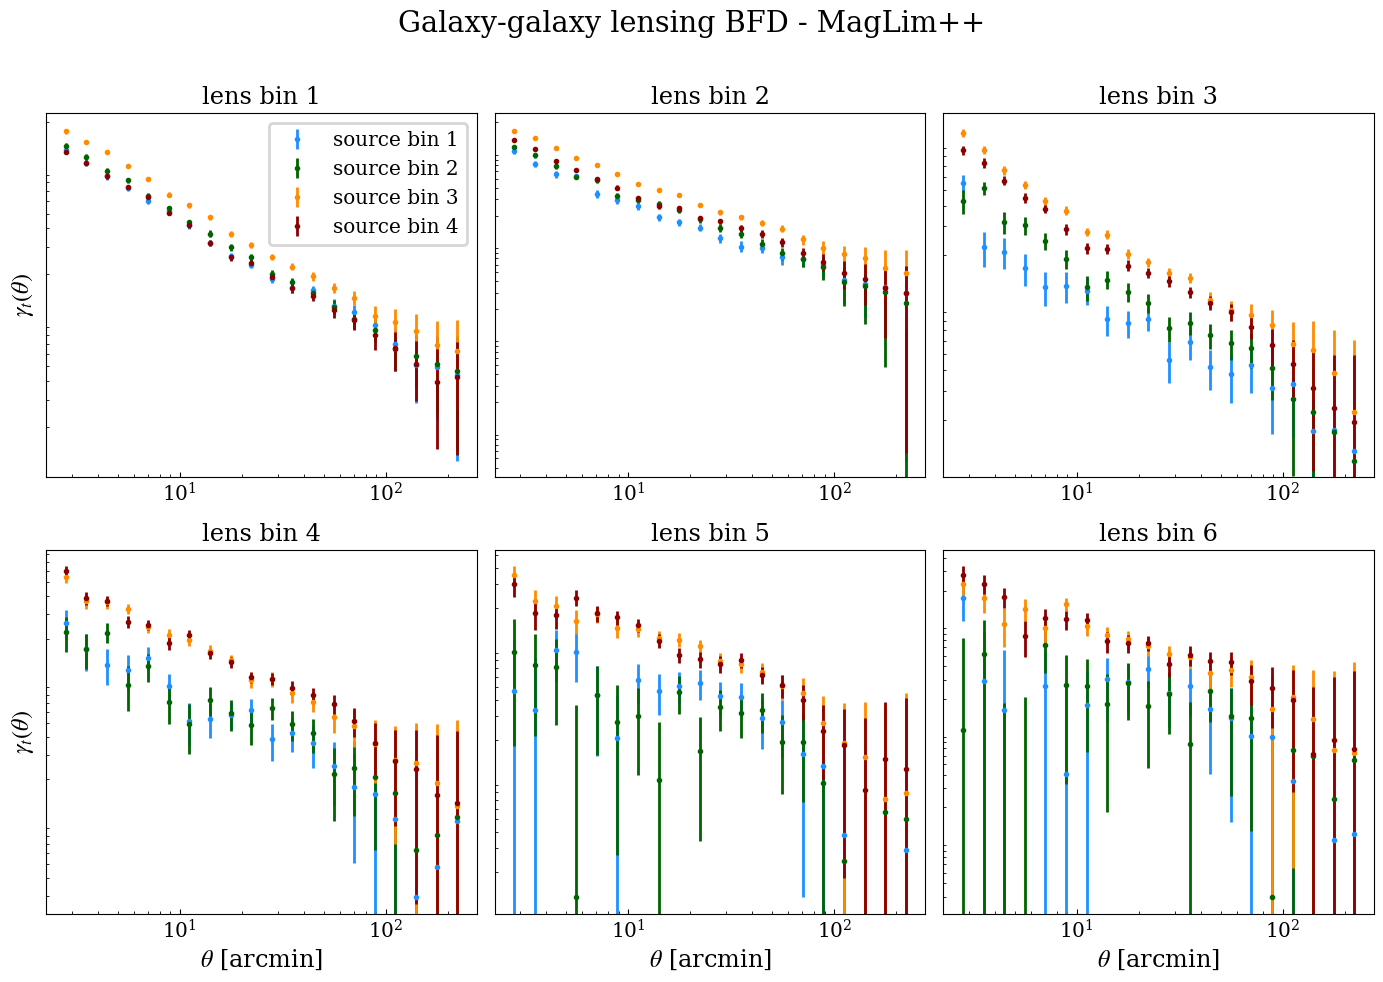

In [33]:
plot_gammat(theta, gammat_tot, gammat_err)

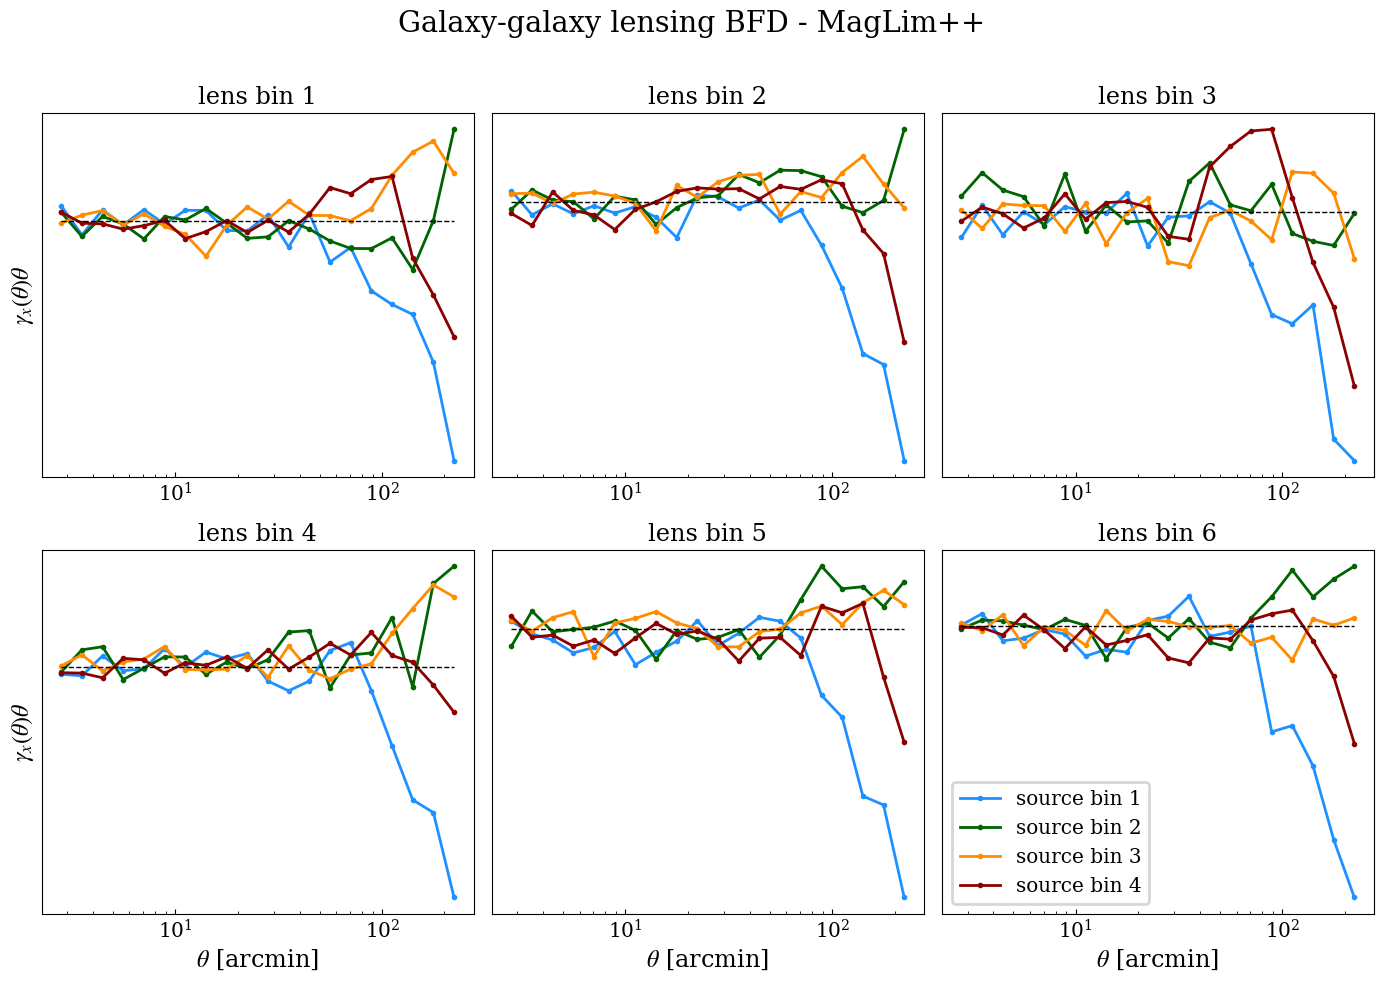

In [27]:
fig = plt.figure(figsize=(14, 10))
plt.suptitle('Galaxy-galaxy lensing BFD - MagLim++\n')

for l in range(zbins_l):
    for s in range(zbins_s):
        
        plt.subplot(2, 3, l+1)
        plt.plot(theta, -gammax[l][s]*theta, marker='.', color=colors[s], label=f'source bin {s+1}')

    plt.title(f'lens bin {l+1}')
    plt.xscale('log')
    plt.hlines(0, min(theta), max(theta), ls='--', lw=1)
    if l in (3, 4, 5): plt.xlabel(r'$\theta$ [arcmin]')
    if l in (0, 3): plt.ylabel(r'$\gamma_x (\theta) \theta$')
    plt.yticks([])

plt.legend()
plt.tight_layout()
fig.patch.set_alpha(1.0)
plt.savefig('gammax_bfd.png', dpi=150, bbox_inches='tight')
plt.show()

## Some extra plots

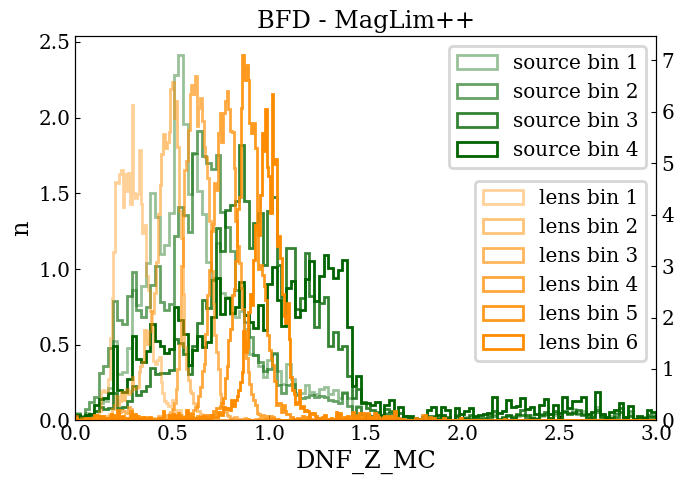

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.title('BFD - MagLim++')

a = np.linspace(0.4, 1, zbins_s)
for s in range(zbins_s):
    ax.hist(bfd_bins[s]['DNF_Z_MC'], histtype='step', color='darkgreen', alpha=a[s], bins=200, density=True, label='source bin '+str(s+1))

ax2 = ax.twinx()
a = np.linspace(0.4, 1, zbins_l)
for l in range(zbins_l):
    ax2.hist(maglim_bins[l]['Z_MC'], histtype='step', color='darkorange', alpha=a[l], bins=500, density=True, label='lens bin '+str(l+1))

ax.set_xlim(0, 3)  
ax.set_xlabel('DNF_Z_MC')
ax.set_ylabel('n')
ax.legend()
ax2.legend(bbox_to_anchor=(1, 0.65))
plt.tight_layout()
fig.patch.set_alpha(1.0)
plt.show()

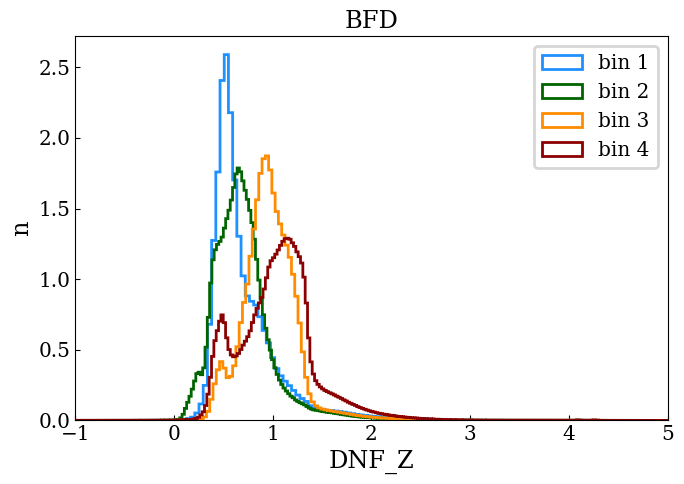

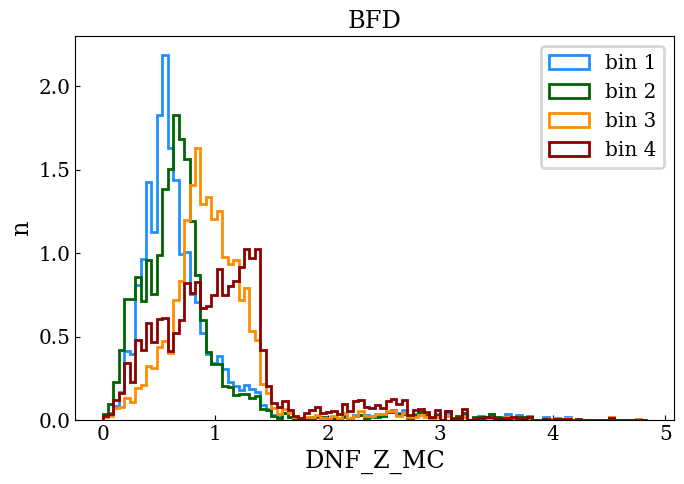

In [14]:
plot_prop(bfd_bins, 'BFD', 'DNF_Z', bins=10000, xlims=[-1,5])
plot_prop(bfd_bins, 'BFD', 'DNF_Z_MC', bins=100)

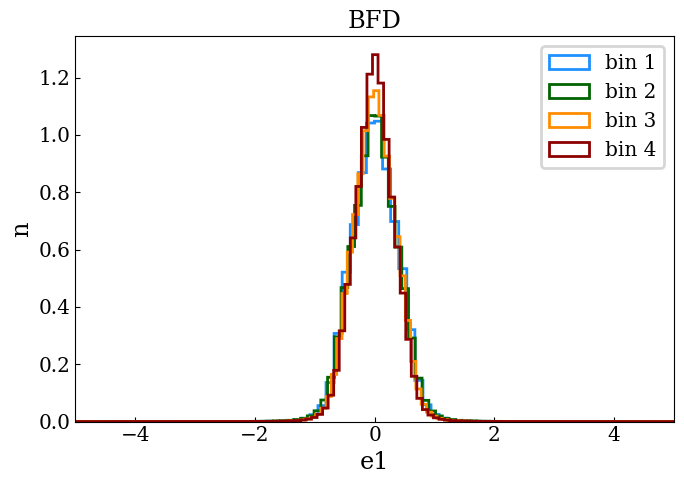

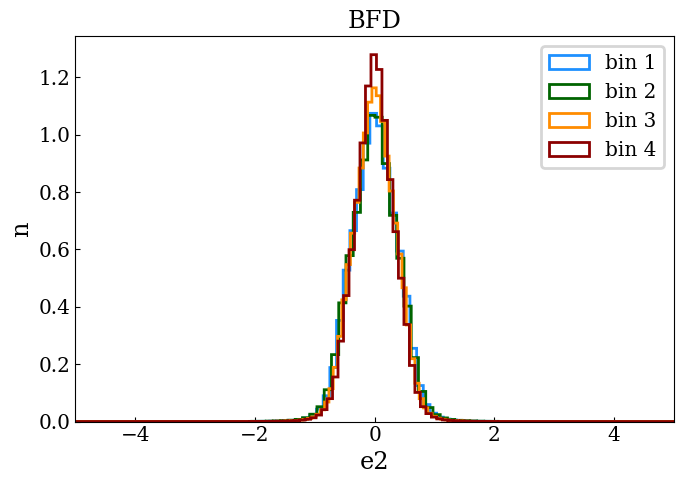

In [15]:
plot_prop(bfd_bins, 'BFD', 'e1', bins=1000, xlims=[-5,5])
plot_prop(bfd_bins, 'BFD', 'e2', bins=1000, xlims=[-5,5])

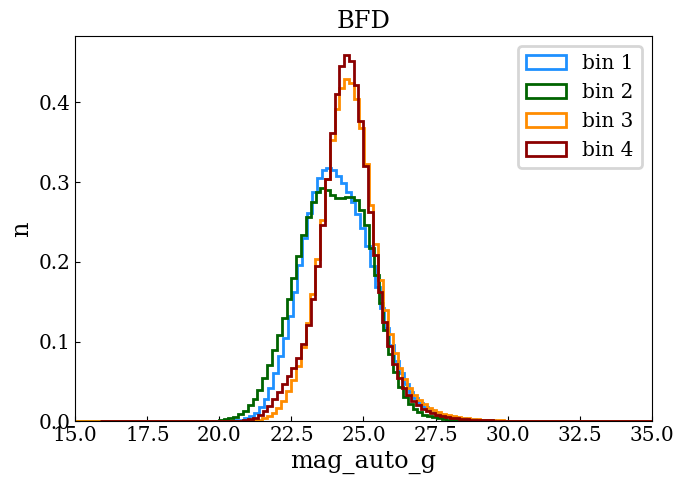

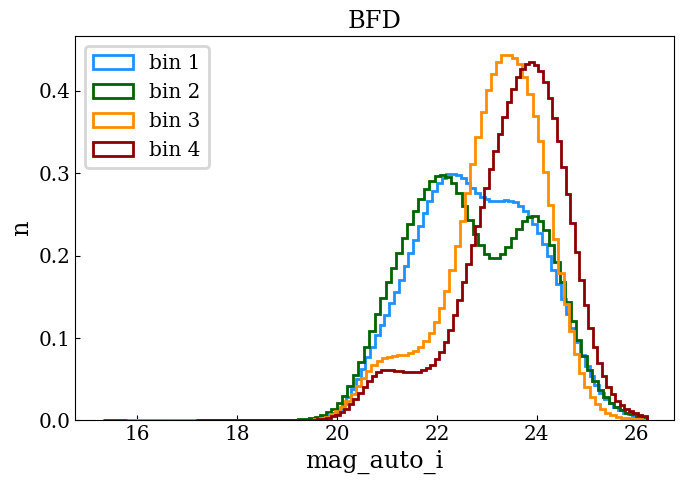

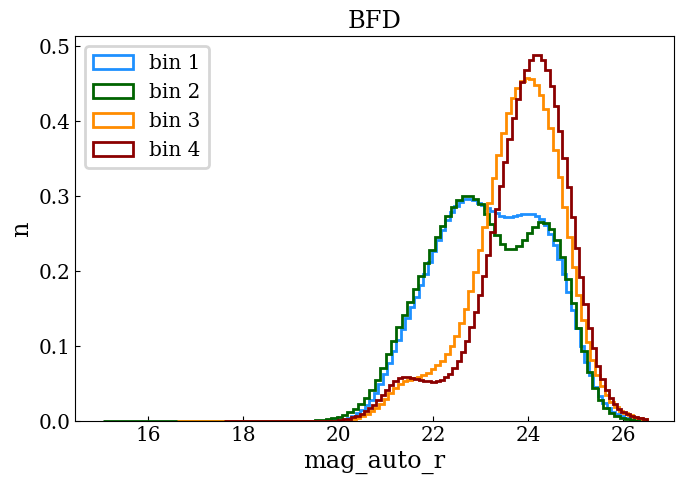

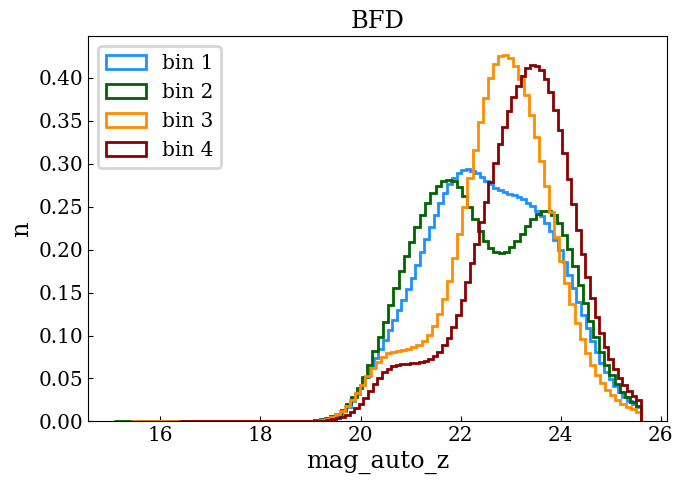

In [16]:
plot_prop(bfd_bins, 'BFD', 'mag_auto_g', bins=500, xlims=[15,35])
plot_prop(bfd_bins, 'BFD', 'mag_auto_i', bins=100)
plot_prop(bfd_bins, 'BFD', 'mag_auto_r', bins=100)
plot_prop(bfd_bins, 'BFD', 'mag_auto_z', bins=100)

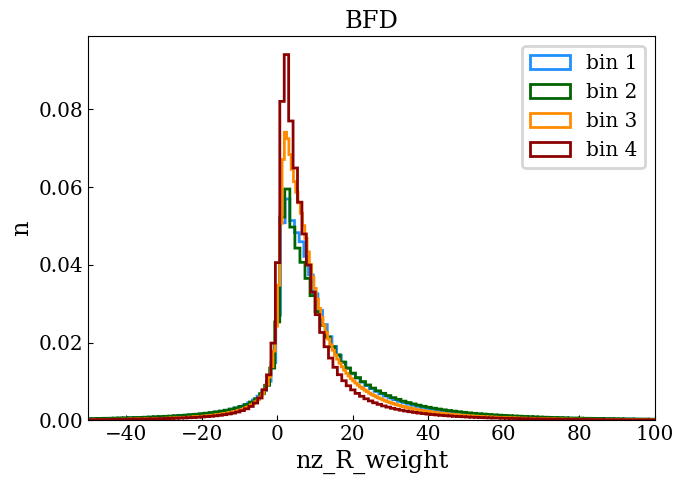

In [17]:
plot_prop(bfd_bins, 'BFD', 'nz_R_weight', bins=50000, xlims=[-50,100])

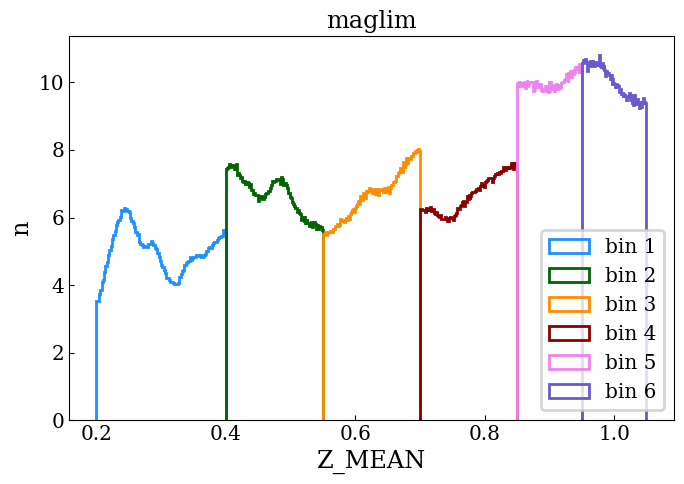

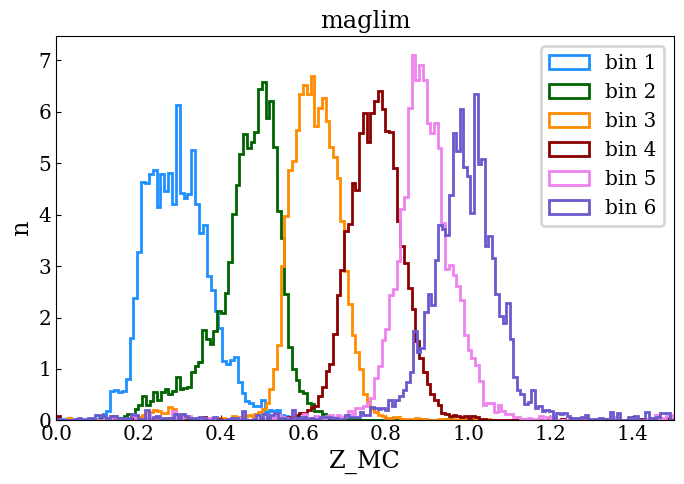

In [18]:
plot_prop(maglim_bins, 'maglim', 'Z_MEAN', bins=100)
plot_prop(maglim_bins, 'maglim', 'Z_MC', bins=500, xlims=[0,1.5])

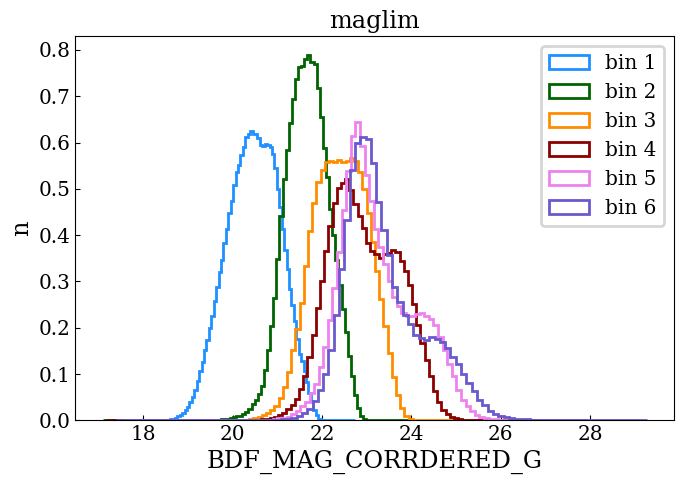

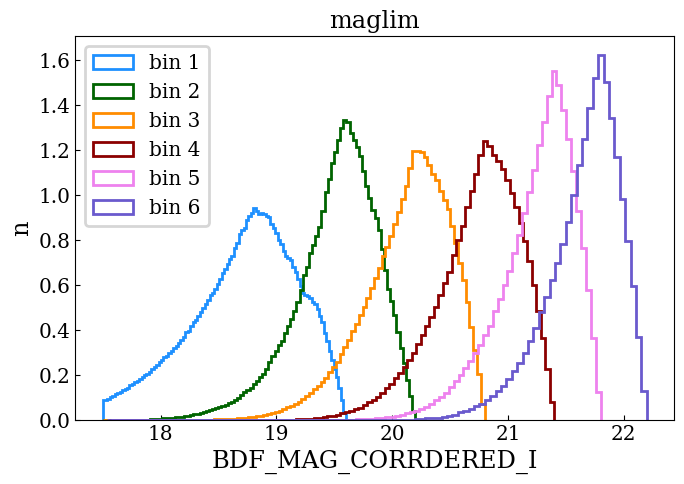

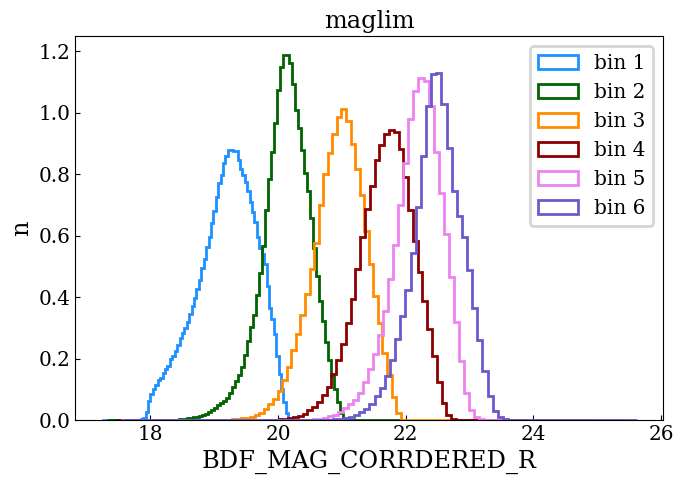

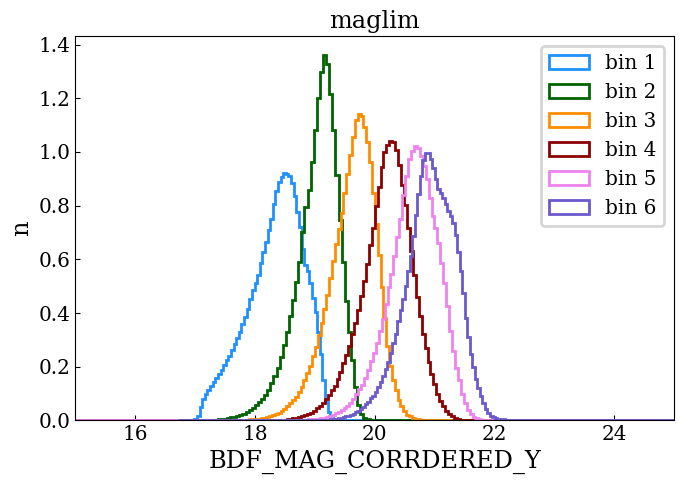

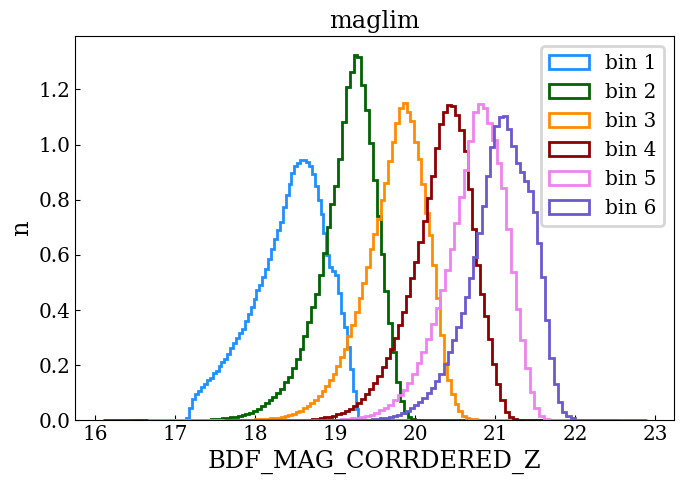

In [19]:
plot_prop(maglim_bins, 'maglim', 'BDF_MAG_CORRDERED_G', bins=100)
plot_prop(maglim_bins, 'maglim', 'BDF_MAG_CORRDERED_I', bins=100)
plot_prop(maglim_bins, 'maglim', 'BDF_MAG_CORRDERED_R', bins=100)
plot_prop(maglim_bins, 'maglim', 'BDF_MAG_CORRDERED_Y', bins=500, xlims=[15,25])
plot_prop(maglim_bins, 'maglim', 'BDF_MAG_CORRDERED_Z', bins=100)

## Compare with Giulia's catalogs

In [37]:
dir_giulia =  '/global/cfs/cdirs/des/giannini/ggl/'
       
print('BFD')
for i in range(zbins_s):
    with fits.open(dir_giulia+f'v5a_sompz_jointmask/bfd_old_bin{i}.fits') as cat:   
        print(f'bin {i}:', len(cat[1].data))
        
print('\nMagLim++')
for i in range(zbins_l):
    with fits.open(dir_giulia+f'v5a_sompz_jointmask/maglim++_bin{i}.fits') as cat:   
        print(f'bin {i}:', len(cat[1].data))

BFD
bin 0: 42396430
bin 1: 42929375
bin 2: 43179517
bin 3: 43652238

MagLim++
bin 0: 1850096
bin 1: 1384948
bin 2: 1426696
bin 3: 1830710
bin 4: 1398087
bin 5: 1399892


**--> Same as mine**